In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix


df = pd.read_csv("/content/PhiUSIIL_Phishing_URL_Dataset.csv", on_bad_lines='skip')

/tmp/ipykernel_2433/770748166.py:9: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/PhiUSIIL_Phishing_URL_Dataset.csv", on_bad_lines='skip')


In [ ]:
print(df.head())
print(df.shape)
print(df.columns)

                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24         0.0  com               100.0              1.000000   
1            16         0.0   de               100.0              0.666667   
2            22         0.0   uk               100.0              0.866667   
3            19         0.0  com               100.0              1.000000   
4            26         0.0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb  ...  Pay  Crypt

In [ ]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
IsHTTPS                       0
NoOfSubDomain                 0
URLLength                     0
IsDomainIP                    0
NoOfOtherSpecialCharsInURL    0
dtype: int64


In [ ]:
features = [
    'IsHTTPS',
    'NoOfSubDomain',
    'URLLength',
    'IsDomainIP',
    'NoOfOtherSpecialCharsInURL'
]

X = df[features]
y = df['label']

In [ ]:
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9720886847958671
Precision: 0.9705917947476703
Recall   : 0.982120989468528
F1 Score : 0.9763223568080832

Confusion Matrix:
[[5528  243]
 [ 146 8020]]


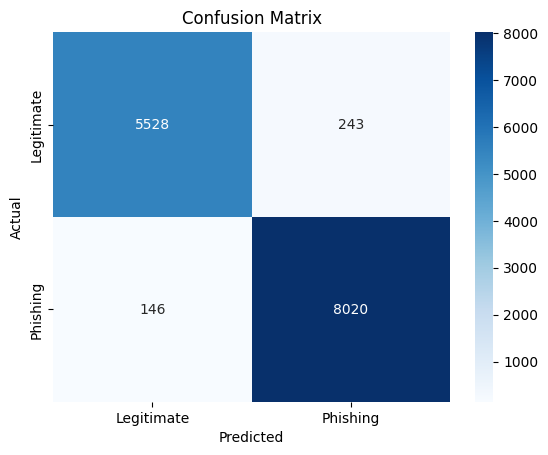

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Phishing'],
    yticklabels=['Legitimate', 'Phishing']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()